In [1]:
from mscg import *

import matplotlib.pyplot as plt

In [2]:
#AA_traj = Trajectory('no_solvent_ions.trr', fmt='trr')
AA_traj = Trajectory('subset.trr', fmt='trr')
AA_traj.read_frame()
AA_traj.x.shape

(337, 3)

In [3]:
from mscg.cli import cgmap

# map atomistic traj to CG traj
#cgmap.main(map='map_dna.yaml', traj='no_solvent_ions.trr', out='CG_2_bead.lammpstrj')
cgmap.main(map='map_dna_subset.yaml', traj='subset.trr', out='CG.lammpstrj')

In [4]:
#CG_traj = Trajectory('CG_2_bead.lammpstrj', fmt='lammpstrj')
CG_traj = Trajectory('CG.lammpstrj', fmt='lammpstrj')
CG_traj.read_frame()
CG_traj.x.shape

(10, 3)

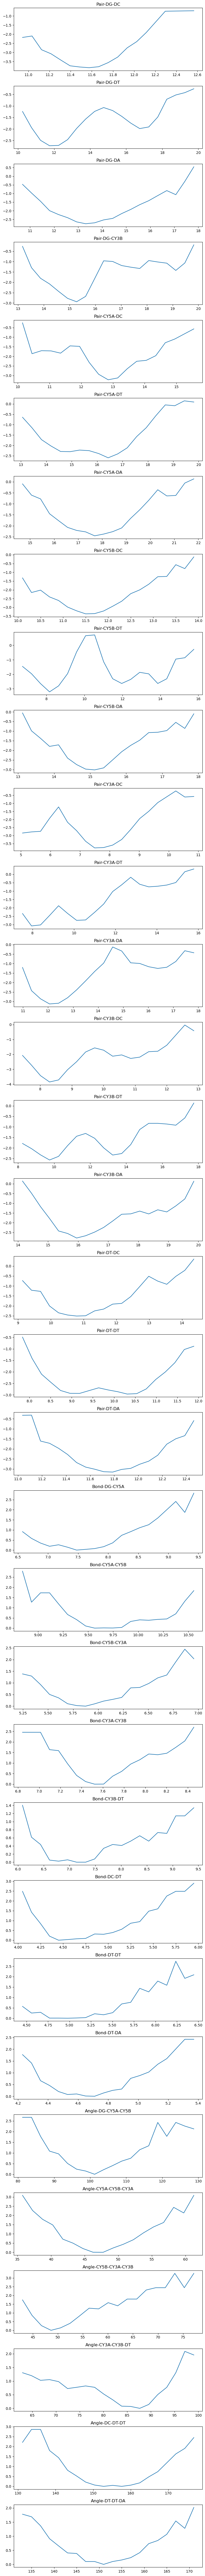

In [7]:
from mscg.cli import cgib

result = cgib.main(
    top     = "0nt_subset_top",
    traj    = "CG.lammpstrj",
    names   = "DG,DT,DA,DC,CY5A,CY5B,CY3A,CY3B",
    cut     = 30.0,
    pair    = [
        'DG,DC,min=10.9,max=12.7,bins=20',
        'DG,DT,min=10,max=20,bins=20',
        'DG,DA,min=10.5,max=18,bins=20',
        'DG,CY3B,min=13,max=20,bins=20',
        'CY5A,DC,min=10,max=16,bins=20',
        'CY5A,DT,min=12.5,max=20,bins=20',
        'CY5A,DA,min=14.5,max=22,bins=20',
        'CY5B,DC,min=10,max=14,bins=20',
        'CY5B,DT,min=6.5,max=16,bins=20',
        'CY5B,DA,min=13,max=18,bins=20',
        'CY3A,DC,min=4.9,max=11,bins=20',
        'CY3A,DT,min=7.3,max=16,bins=20',
        'CY3A,DA,min=10.8,max=18,bins=20',
        'CY3B,DC,min=7.3,max=13,bins=20',
        'CY3B,DT,min=8,max=18,bins=20',
        'CY3B,DA,min=14,max=20,bins=20',
        'DT,DC,min=9,max=14.5,bins=20',
        'DT,DT,min=7.5,max=12,bins=20',
        'DT,DA,min=11,max=12.5,bins=20'
    ],
    bond    = [
        'DG,CY5A,min=6.5,max=9.5,bins=20',
        'CY5A,CY5B,min=8.8,max=10.6,bins=20',
        'CY5B,CY3A,min=5.2,max=7.0,bins=20',
        'CY3A,CY3B,min=6.8,max=8.5,bins=20',
        'CY3B,DT,min=6.0,max=9.5,bins=20',
        'DC,DT,min=4.0,max=6.0,bins=20',
        'DT,DT,min=4.4,max=6.5,bins=20',
        'DT,DA,min=4.2,max=5.4,bins=20'
    ],
    angle    = [
        'DG,CY5A,CY5B,min=80,max=130,bins=20',
        'CY5A,CY5B,CY3A,min=35,max=65,bins=20',
        'CY5B,CY3A,CY3B,min=42,max=80,bins=20',
        'CY3A,CY3B,DT,min=62,max=100,bins=20',
        'DC,DT,DT,min=130,max=178,bins=20',
        'DT,DT,DA,min=132,max=172,bins=20'
    ],
    save    = "return"
)

fig, axes = plt.subplots(len(result), 1, figsize=(8, 3 * len(result)))
for ax, r in zip(axes, result):
    hist = r['data']
    ax.plot(hist[:, 0], hist[:, 2])
    ax.set_title(r.get('name', ''))
plt.tight_layout()
plt.show()

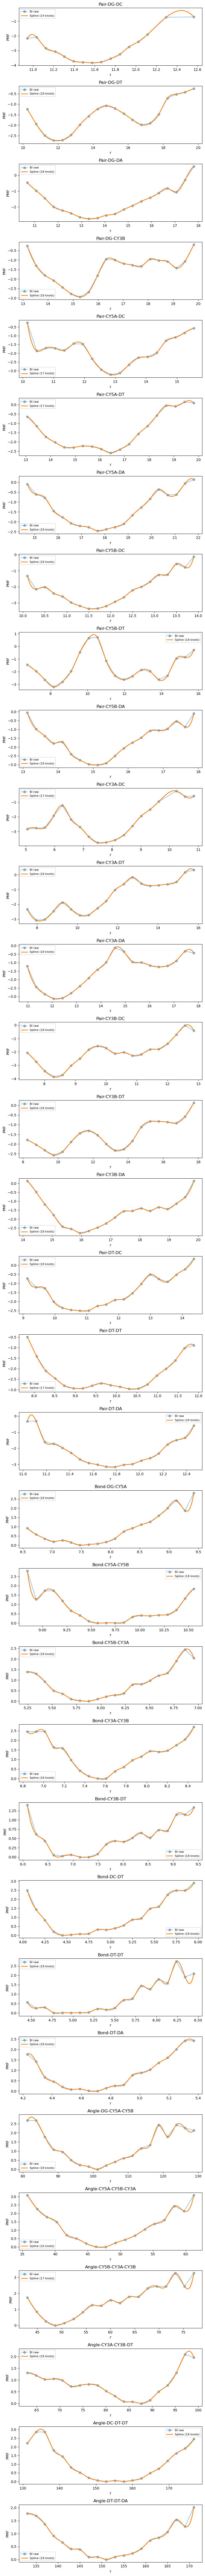

Saved: splines/model.txt


In [8]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter
import numpy as np
import os

fig, axes = plt.subplots(len(result), 1, figsize=(8, 3 * len(result)))

splines = {}

for ax, r in zip(axes, result):
    hist = r['data']
    x = hist[:, 0]
    pmf = hist[:, 2]
    name = r.get('name', '')

    mask = np.isfinite(pmf)
    x_clean, pmf_clean = x[mask], pmf[mask]

    pmf_sg = savgol_filter(pmf_clean, window_length=3, polyorder=2)
    spl = UnivariateSpline(x_clean, pmf_sg, k=3, s=0)

    x_fine = np.linspace(x_clean[0], x_clean[-1], 300)
    ax.plot(x_clean, pmf_clean, 'o-', alpha=0.5, label='BI raw')
    ax.plot(x_fine, spl(x_fine), '-', lw=2, label=f'Spline ({len(spl.get_knots())} knots)')
    ax.set_title(name)
    ax.set_xlabel('r')
    ax.set_ylabel('PMF')
    ax.legend(fontsize=8)

    splines[name] = (spl, x_clean)

plt.tight_layout()
plt.show()

os.makedirs("splines", exist_ok=True)
with open("splines/model.txt", "w") as f:
    for name, (spl, x_clean) in splines.items():
        x_min = round(float(x_clean[0]), 6)
        x_max = round(float(x_clean[-1]), 6)
        n_intervals = 20

        x_uniform = np.linspace(x_min, x_max, n_intervals + 1)
        pmf_uniform = spl(x_uniform)
        spl_uniform = UnivariateSpline(x_uniform, pmf_uniform, k=3, s=0)
        t, c, k = spl_uniform._eval_args
        c_trimmed = c[:len(t) - k - 1]

        interaction_type, safe_name = name.split("-", 1)

        coeff_str = " ".join(f"{v:.6g}" for v in c_trimmed)
        f.write(f"{interaction_type}_{safe_name} {x_min} {x_max} {x_min} L2 {coeff_str}\n")

print("Saved: splines/model.txt")

In [ ]:
from mscg.cli import cgderiv

result = cgderiv.main(
    top     = "0nt_subset_top",
    traj    = "CG.lammpstrj",
    names   = "DG,DT,DA,DC,CY5A,CY5B,CY3A,CY3B",
    cut     = 30.0,
    pair    = [
        'model=BSpline,type=DG:DC,min=10.9,max=12.7,resolution=0.1',
        'model=BSpline,type=DG:DT,min=10,max=20,resolution=0.1',
        'model=BSpline,type=DG:DA,min=10.5,max=18,resolution=0.1',
        'model=BSpline,type=DG:CY3B,min=13,max=20,resolution=0.1',
        'model=BSpline,type=CY5A:DC,min=10,max=16,resolution=0.1',
        'model=BSpline,type=CY5A:DT,min=12.5,max=20,resolution=0.1',
        'model=BSpline,type=CY5A:DA,min=14.5,max=22,resolution=0.1',
        'model=BSpline,type=CY5B:DC,min=10,max=14,resolution=0.1',
        'model=BSpline,type=CY5B:DT,min=6.5,max=16,resolution=0.1',
        'model=BSpline,type=CY5B:DA,min=13,max=18,resolution=0.1',
        'model=BSpline,type=CY3A:DC,min=4.9,max=11,resolution=0.1',
        'model=BSpline,type=CY3A:DT,min=7.3,max=16,resolution=0.1',
        'model=BSpline,type=CY3A:DA,min=10.8,max=18,resolution=0.1',
        'model=BSpline,type=CY3B:DC,min=7.3,max=13,resolution=0.1',
        'model=BSpline,type=CY3B:DT,min=8,max=18,resolution=0.1',
        'model=BSpline,type=CY3B:DA,min=14,max=20,resolution=0.1',
        'model=BSpline,type=DT:DC,min=9,max=14.5,resolution=0.1',
        'model=BSpline,type=DT:DT,min=7.5,max=12,resolution=0.1',
        'model=BSpline,type=DT:DA,min=11,max=12.5,resolution=0.1'
    ],
    bond    = [
        'model=BSpline,type=DG:CY5A,min=6.5,max=9.5,resolution=0.1',
        'model=BSpline,type=CY5A:CY5B,min=8.8,max=10.6,resolution=0.1',
        'model=BSpline,type=CY5B:CY3A,min=5.2,max=7.0,resolution=0.1',
        'model=BSpline,type=CY3A:CY3B,min=6.8,max=8.5,resolution=0.1',
        'model=BSpline,type=CY3B:DT,min=6.0,max=9.5,resolution=0.1',
        'model=BSpline,type=DC:DT,min=4.0,max=6.0,resolution=0.1',
        'model=BSpline,type=DT:DT,min=4.4,max=6.5,resolution=0.1',
        'model=BSpline,type=DT:DA,min=4.2,max=5.4,resolution=0.1'
    ],
    angle    = [
        'model=BSpline,type=DG:CY5A:CY5B,min=80,max=130,resolution=0.2,order=3',
        'model=BSpline,type=CY5A:CY5B:CY3A,min=35,max=65,resolution=0.2,order=3',
        'model=BSpline,type=CY5B:CY3A:CY3B,min=42,max=80,resolution=0.2,order=3',
        'model=BSpline,type=CY3A:CY3B:DT,min=62,max=100,resolution=0.2,order=3',
        'model=BSpline,type=DC:DT:DT,min=130,max=178,resolution=0.2,order=3',
        'model=BSpline,type=DT:DT:DA,min=132,max=172,resolution=0.2,order=3'
    ],
    save    = "model_ref"
)